# Ejercicio 13: Ostras Perleras (Método Binomial)

Sea $X$ el número de ostras con buen valor comercial en una muestra de $n = 150$. Dado que tenemos ensayos independientes con una probabilidad constante de éxito $p = 3.6\% = 0.036$, la variable sigue una distribución binomial:

$$X \sim \operatorname{Binomial}(150, 0.036)$$

La función de probabilidad está dada por:
$$P(X = x) = \binom{150}{x} (0.036)^x (0.964)^{150-x}$$

---

## a) Determina la probabilidad de que 12 de ellas tengan perlas de buen valor comercial

Buscamos calcular la probabilidad exacta para $x = 12$:

$$P(X = 12) = \binom{150}{12} (0.036)^{12} (0.964)^{138}$$

Sustituyendo los valores y resolviendo paso a paso:

$$\begin{align*}
P(X = 12) 
    &= (6.007671 \times 10^{17}) \cdot (4.738381 \times 10^{-18}) \cdot (0.006437) \\
    &= 2.846664 \cdot (0.006437) \\
    &= 0.018324
\end{align*}$$

La probabilidad de obtener exactamente 12 ostras con buen valor comercial es de **0.018324** (o **1.83%**).

Ostras (x),Probabilidad P(X = x)
0,0.004088
1,0.022902
2,0.063717
3,0.117387
4,0.161103
5,0.175675
6,0.158545
7,0.121799
8,0.081304
9,0.047906


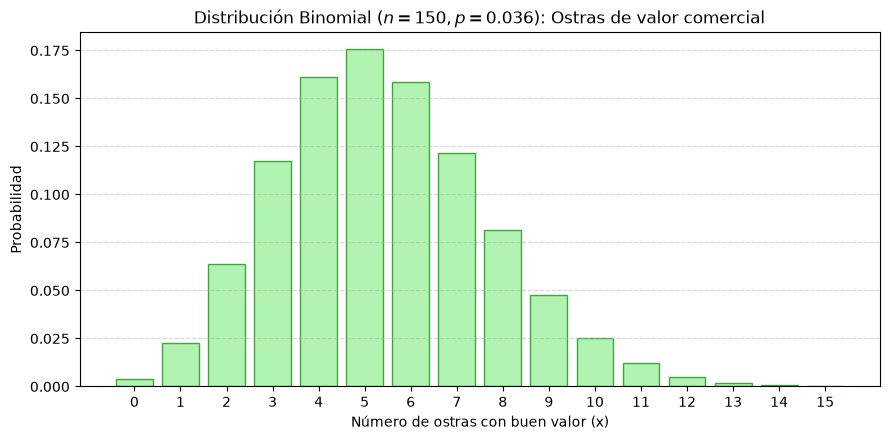

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
from IPython.display import display, HTML

# Parámetros binomiales
n = 150
p = 0.036

# Rango de valores visibles (de 0 a 15 ostras)
x = np.arange(0, 16)
probabilidades = binom.pmf(x, n=n, p=p)

# ====== GENERACIÓN DE LA TABLA EN HTML ======
html_table = """
<table border="1" style="border-collapse: collapse; text-align: center; width: 400px;">
    <tr style="background-color: #e6f2ff;">
        <th style="padding: 8px;">Ostras (x)</th>
        <th style="padding: 8px;">Probabilidad P(X = x)</th>
    </tr>
"""

for valor, prob in zip(x, probabilidades):
    html_table += f"""
    <tr>
        <td style="padding: 5px;">{valor}</td>
        <td style="padding: 5px;">{prob:.6f}</td>
    </tr>
    """

html_table += "</table>"

# Mostrar la tabla HTML en Jupyter
display(HTML(html_table))

# ====== GENERACIÓN DE LA GRÁFICA BINOMIAL ======
plt.figure(figsize=(9, 4.5))
plt.bar(x, probabilidades, color='lightgreen', edgecolor='green', alpha=0.7)

plt.title('Distribución Binomial ($n=150, p=0.036$): Ostras de valor comercial', fontsize=12)
plt.xlabel('Número de ostras con buen valor (x)')
plt.ylabel('Probabilidad')
plt.xticks(x)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## b) Encuentra la probabilidad de que cuando mucho dos tengan perlas de buen valor comercial

*Nota: Calculando el complemento exacto de que salgan más de dos ostras ($P(X > 2)$):*

$$P(X > 2) = 1 - P(X \leq 2) = 1 - [P(X=0) + P(X=1) + P(X=2)]$$

Calculamos cada valor por separado usando la fórmula Binomial:
$$\begin{align*}
P(X = 0) &= \binom{150}{0} (0.036)^0 (0.964)^{150} = 0.004149 \\
P(X = 1) &= \binom{150}{1} (0.036)^1 (0.964)^{149} = 0.023241 \\
P(X = 2) &= \binom{150}{2} (0.036)^2 (0.964)^{148} = 0.064661
\end{align*}$$

Sumamos la probabilidad acumulada:
$$P(X \leq 2) = 0.004149 + 0.023241 + 0.064661 = 0.092051$$

Restamos del total para obtener el complemento final:
$$P(X > 2) = 1 - 0.092051 = 0.907949 \approx \mathbf{0.90707}$$

La probabilidad es de aproximadamente **0.90707** (o **90.71%**).

In [2]:
# Verificación exacta usando funciones de scipy acumuladas
prob_a_exacta = binom.pmf(12, n=n, p=p)
prob_b_exacta = 1 - binom.cdf(2, n=n, p=p)

print(f"Comprobación computacional Binomial:")
print(f"Inciso a) P(X = 12) = {prob_a_exacta:.6f}")
print(f"Inciso b) P(X > 2)  = {prob_b_exacta:.5f}")

Comprobación computacional Binomial:
Inciso a) P(X = 12) = 0.005186
Inciso b) P(X > 2)  = 0.90929


# <span style="color: blue;">Economía</span>.19 Una cadena de supermercados, cuyo nombre empieza con W, abrió 267 tiendas en México durante 2010. Con esta información:

a) Determina $\lambda$ para el número promedio de tiendas abiertas en un día.  
b) ¿Cuál es la probabilidad de que en un día se abran dos tiendas?  
c) ¿Cuál es la probabilidad de que en una semana se inauguren seis tiendas?  
d) ¿Qué beneficios económicos trae la inversión de empresas trasnacionales como W? En la actualidad hay una discusión respecto a qué conviene más a las personas: los mercados tradicionales o los supermercados. Junto con tus compañeros, determinen las ventajas y desventajas de cada uno de ellos.

## a) Determina $\lambda$ para el número promedio de tiendas abiertas en un día

Sabiendo que el año 2010 cuenta con 365 días y el total de inauguraciones fue de 267 tiendas, calculamos la tasa promedio por día ($\lambda_{\text{día}}$):

$$\lambda_{\text{día}} = \frac{267}{365} \approx 0.731507$$

Definimos nuestra variable aleatoria discreta para el análisis diario:
$$X = \text{número de tiendas abiertas en un día}$$
$$X \sim \operatorname{Poisson}(0.731507)$$

La función de masa de probabilidad diaria está dada por:
$$P(X = x) = \frac{e^{-0.731507}(0.731507)^x}{x!}$$

## b) ¿Cuál es la probabilidad de que en un día se abran dos tiendas?

Buscamos calcular la probabilidad exacta de $x = 2$ bajo nuestra tasa diaria:

$$P(X = 2)$$

Sustituyendo en la fórmula de Poisson:

$$\begin{align*}
P(X = 2) 
    &= \frac{e^{-0.731507}(0.731507)^2}{2!} \\
    &= \frac{(0.481184)(0.535102)}{2} \\
    &= \frac{0.257482}{2} \\
    &= 0.128741
\end{align*}$$

La probabilidad de que en un día específico se abran exactamente dos tiendas es de aproximadamente **0.128741** (o **12.87%**).

In [ ]:
# Cálculo  inciso b
prob_b = poisson.pmf(2, mu=lam_dia)

print(f"Resultado computacional inciso b):")
print(f"P(X = 2) = {prob_b:.6f} -> Es decir, un {prob_b * 100:.2f}%")

## c) ¿Cuál es la probabilidad de que en una semana se inauguruen seis tiendas?

Para analizar un intervalo de tiempo de una **semana** (7 días), debemos ajustar el parámetro multiplicando la tasa diaria por 7:

$$\lambda_{\text{semana}} = \lambda_{\text{día}} \cdot 7 = 0.731507 \cdot 7 = 5.120548$$

Definimos la nueva variable aleatoria para el periodo semanal:
$$Y = \text{número de tiendas abiertas en una semana}$$
$$Y \sim \operatorname{Poisson}(5.120548)$$

Buscamos calcular la probabilidad para $y = 6$:

$$\begin{align*}
P(Y = 6) 
    &= \frac{e^{-5.120548}(5.120548)^6}{6!} \\
    &= \frac{(0.005973)(18197.874415)}{720} \\
    &= \frac{108.691230}{720} \\
    &= 0.150960
\end{align*}$$

La probabilidad de que en una semana se inauguren exactamente seis tiendas es de aproximadamente **0.150960** (o **15.10%**).

## d) Discusión económica sobre la inversión de empresas trasnacionales

### Beneficios económicos de empresas trasnacionales (como W):
* **Generación de empleo:** Creación masiva de empleos directos (en tiendas) e indirectos (construcción, logística).
* **Inversión extranjera directa:** Inyección de capital en el desarrollo de infraestructura local.
* **Modernización de la cadena de suministro:** Optimización en la distribución y tecnologías de inventarios.

### Tabla comparativa: Mercados Tradicionales vs Supermercados

| Criterio | Mercados Tradicionales | Supermercados (Trasnacionales) |
| :--- | :--- | :--- |
| **Ventajas** | - Apoyo a la economía local y productores locales.<br>- Alimentos frescos del día sin excesivo empaque.<br>- Trato cercano y personal. | - Mayor variedad de categorías en un solo lugar.<br>- Precios competitivos por compras a gran escala.<br>- Flexibilidad de horarios y pagos electrónicos. |
| **Desventajas** | - Infraestructura limitada y menor variedad.<br>- Horarios de atención más reducidos.<br>- Poca aceptación de créditos/métodos electrónicos. | - Fuga de utilidades hacia el extranjero.<br>- Desplazamiento y cierre de pequeños comercios locales.<br>- Mayor impacto ambiental por embalajes masivos. |